## **Imports**

In [1]:
import torch
import torchvision
from tqdm import tqdm_notebook as tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from torchsummary import summary
from torch.utils.data import random_split
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
from torchvision.datasets import VOCDetection
import torchvision.datasets as datasets

In [3]:
import os

In [4]:
from __future__ import division
from math import sqrt as sqrt
from itertools import product as product
from torch.autograd import Variable
from torch.autograd import Function
import torch.nn.init as init

In [5]:
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device=torch.device('cpu')
device

device(type='cuda', index=0)

## **Albumentations**

### **Installation**

In [ ]:
!pip install albumentations

In [6]:
import albumentations as A
import cv2

/home/simens/Envs/default_python_pkgs/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.1'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### **Make our first detection Albumentation**

In [7]:
image = cv2.imread('detection.jpg')

#### **Look at it**

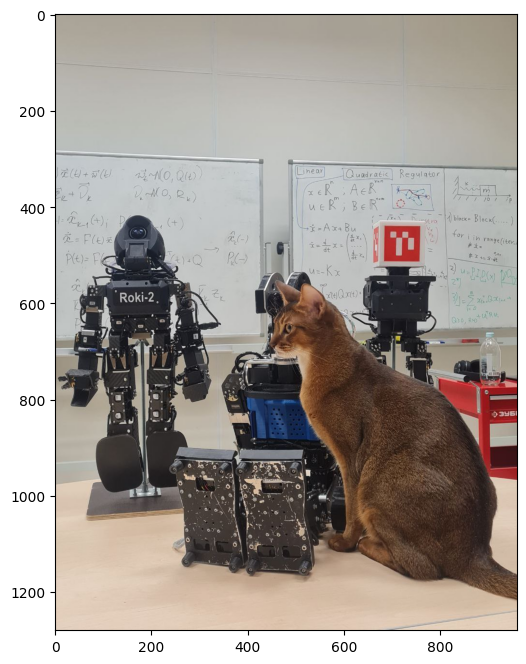

In [8]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, figsize=(8, 8))

# Display the image
ax.imshow(image)

#### **Let's label it**

https://app.roboflow.com

Add pictures to RoboFlow, Annotate them, Create dataset, Download it

In [ ]:
!unzip robots_and_cat.v1i.coco.zip

#### **Get annotations**

In [9]:
input_file = "train/annotations.coco.json"

In [10]:
with open(input_file, "r") as f:
    coco_json = json.load(f)

categories = {category["id"]: category["name"] for category in coco_json["categories"]}

bbs_with_anotations = []
for annotation in coco_json["annotations"]:
    image_id = annotation["image_id"]
    category_id = annotation["category_id"]
    category_name = categories[category_id]
    bbox = annotation["bbox"]  # COCO format: [x_min, y_min, width, height]
    
    bbs_with_anotations.append({
        "image_id": image_id,
        "category_id": category_id,
        "category_name": category_name,
        "bbox": bbox
    })

In [11]:
for bb in bbs_with_anotations:
    print(bb)

{'image_id': 0, 'category_id': 2, 'category_name': 'roki2', 'bbox': [19, 407, 313.33, 593.33]}
{'image_id': 0, 'category_id': 3, 'category_name': 'roki3', 'bbox': [629, 420, 165.56, 356.67]}
{'image_id': 0, 'category_id': 1, 'category_name': 'cat', 'bbox': [443, 550, 516.67, 670]}
{'image_id': 0, 'category_id': 4, 'category_name': 'sahr', 'bbox': [241, 509, 377.78, 664.44]}


#### **Make augmentations**

In [12]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
], bbox_params=A.BboxParams(format = 'coco', label_fields = ['labels']))

In [13]:
bbs = [bb['bbox'] for bb in bbs_with_anotations]
classes = [bb['category_name'] for bb in bbs_with_anotations]

In [14]:
transformed = transform(image=image, bboxes=bbs, labels=classes)

In [15]:
transformed_image = transformed['image']
transformed_bboxes = transformed['bboxes']  # Transformed bounding boxes in COCO format

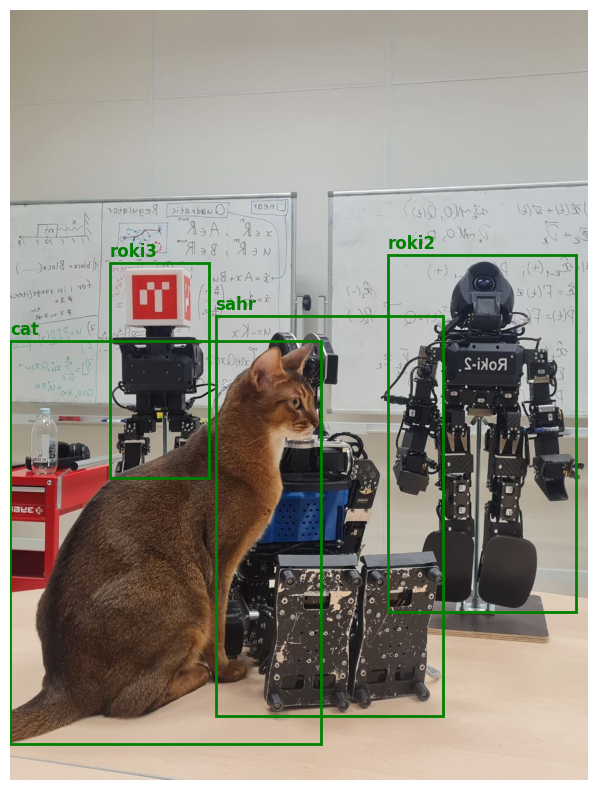

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(transformed_image)

for bbox, class_name in zip(transformed_bboxes, classes):
    x_min, y_min, width, height = bbox
    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, fill=False, edgecolor="green", linewidth=2))
    ax.text(x_min, y_min - 10, class_name, color='green', fontsize=12, fontweight='bold')

plt.axis("off")
plt.show()

#### **Make augmentations (Corner cases)**

In [17]:
transform = A.Compose([
    A.CenterCrop(width=340, height=340, p=1),
], bbox_params=A.BboxParams(format = 'coco', min_area=10000, label_fields = ['labels'])) # min_visibility=0.3

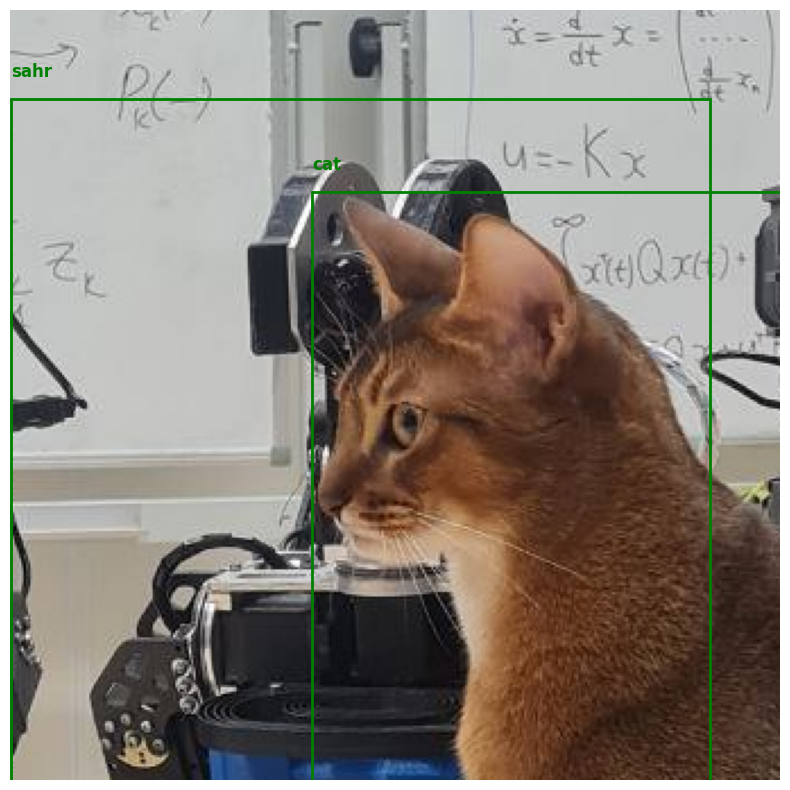

In [18]:
transformed = transform(image=image, bboxes=bbs, labels=classes)

transformed_image = transformed['image']
transformed_bboxes = transformed['bboxes']  # Transformed bounding boxes in COCO format
transformed_classes = transformed['labels']

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(transformed_image)

for bbox, class_name in zip(transformed_bboxes, transformed_classes):
    x_min, y_min, width, height = bbox
    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, fill=False, edgecolor="green", linewidth=2))
    ax.text(x_min, y_min - 10, class_name, color='green', fontsize=12, fontweight='bold')

plt.axis("off")
plt.show()

In [19]:
transformed['bboxes']

[[132.99999237060547, 80.0, 207.00000762939453, 260.0],
 [0.0, 39.00001525878906, 308.7800407409668, 300.99998474121094]]

#### **Multiple Images**

In [20]:
next_image = cv2.imread('cat.jpg')
next_image = cv2.cvtColor(next_image, cv2.COLOR_BGR2RGB)
next_bbs = [(300,350,450, 750)]
next_classes = ['cat']

In [21]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format = 'coco', min_visibility=0.2, label_fields = ['labels']))

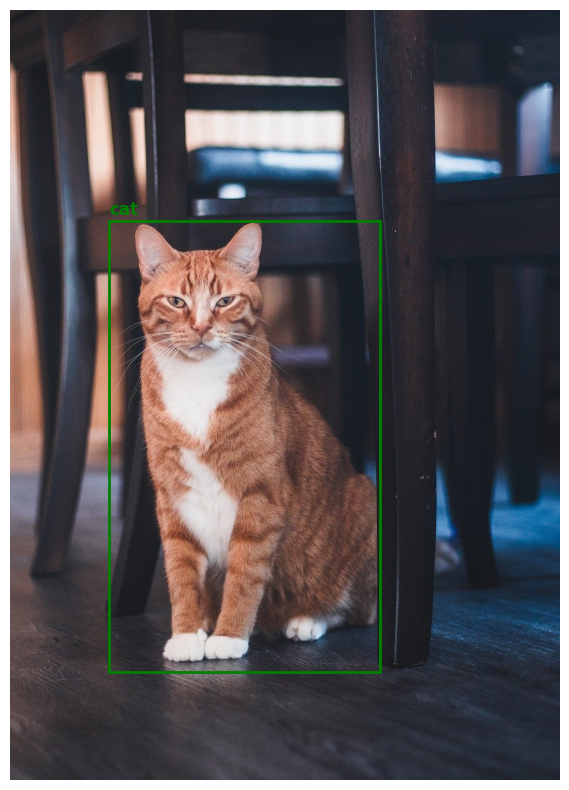

In [22]:
transformed = transform(image=next_image, bboxes=next_bbs, labels=next_classes)

transformed_image = transformed['image']
transformed_bboxes = transformed['bboxes']  # Transformed bounding boxes in COCO format

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(transformed_image)

for bbox, class_name in zip(transformed_bboxes, next_classes):
    x_min, y_min, width, height = bbox
    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, fill=False, edgecolor="green", linewidth=2))
    ax.text(x_min, y_min - 10, class_name, color='green', fontsize=12, fontweight='bold')

plt.axis("off")
plt.show()

#### **MixUp for classification problem**

In [23]:
image.shape

(1280, 960, 3)

In [24]:
next_image = cv2.resize(next_image, (960, 1280))
next_image.shape

(1280, 960, 3)

SAHR, Roki2, Roki3, cat

In [25]:
labels = np.array([[1.], [1.], [1.], [1.]])
next_labels = np.array([[0.], [0.], [0.], [1.]])

In [26]:
def mixup(alpha, img1, img2, label1, label2):
    img1 = img1.astype(np.float32) / 255.0
    img2 = img2.astype(np.float32) / 255.0
    mixed_img = alpha * img1 + (1 - alpha) * img2
    mixed_label = alpha * label1 + (1 - alpha) * label2 
    return mixed_img, mixed_label

In [27]:
mixed_img, mixed_label = mixup(0.5, image, next_image, labels, next_labels)
mixed_label

array([[0.5],
       [0.5],
       [0.5],
       [1. ]])

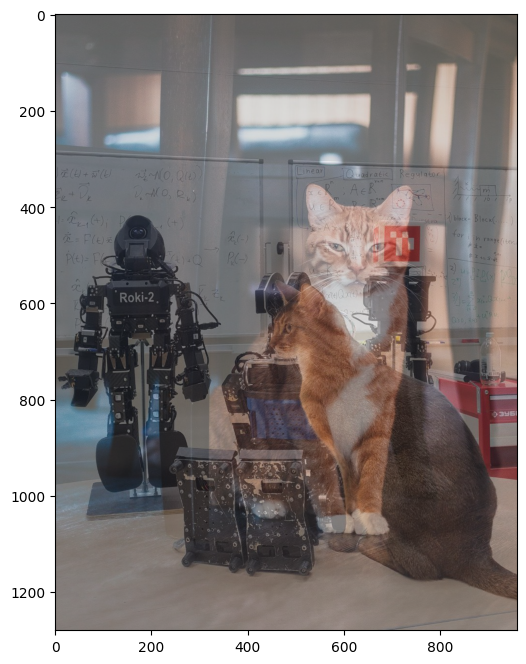

In [28]:
fig, ax = plt.subplots(1, figsize=(8, 8))

ax.imshow(mixed_img)

## **SSD Implementation**

https://github.com/amdegroot/ssd.pytorch/tree/5b0b77faa955c1917b0c710d770739ba8fbff9b7

### **Building SSD 300**

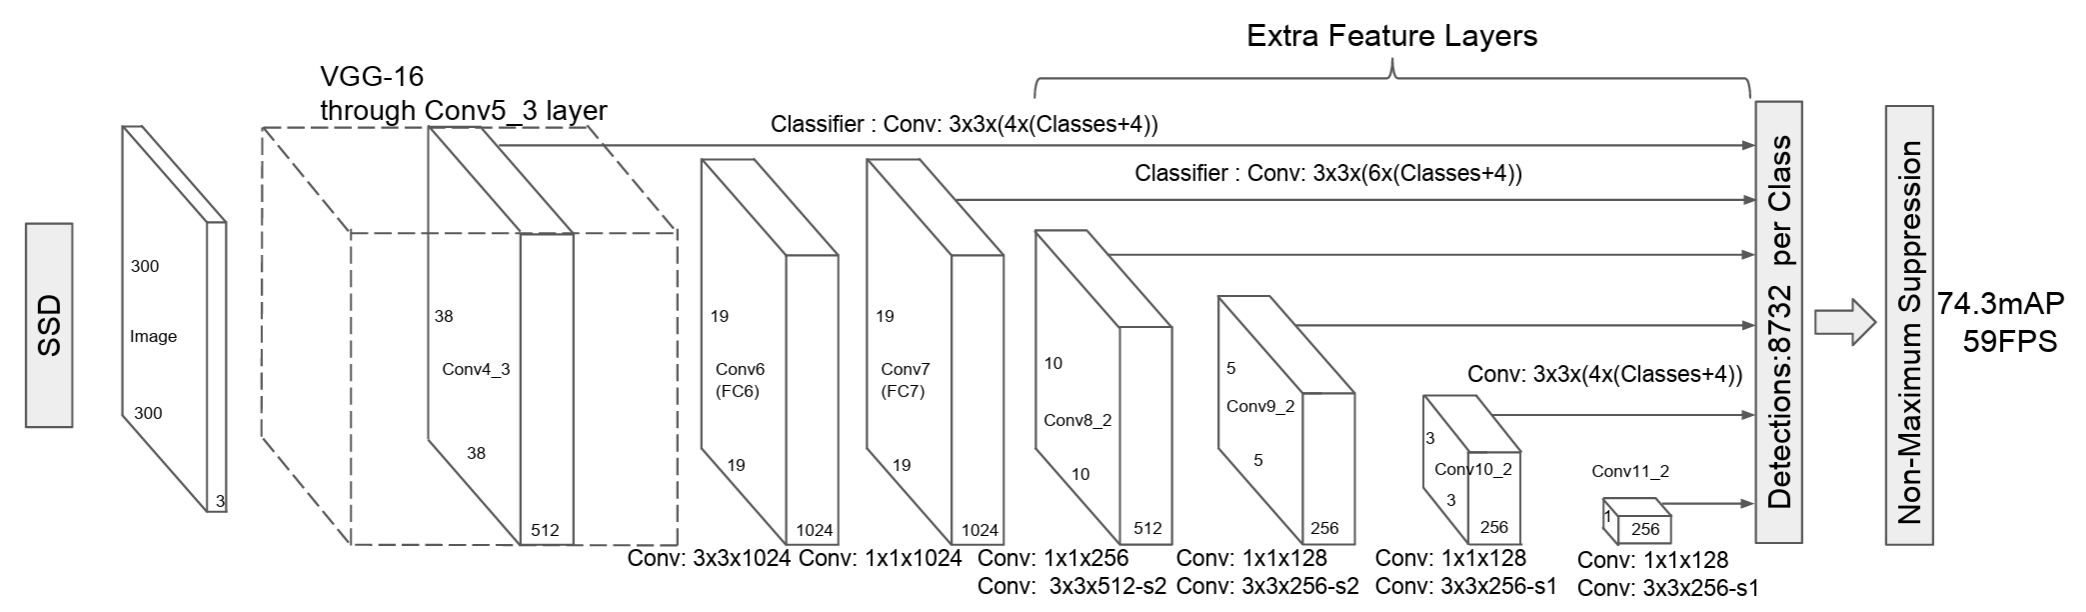

#### **VGG base part**

'M' - max pooling layer

'C' - max pooling layer with **ceil mode** (output size is specified in different way)

In [7]:
base = {
    '300': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'C', 512, 512, 512, 'M',
            512, 512, 512],
}

In [8]:
def vgg(cfg, i, batch_norm=False):
    layers = []
    in_channels = i
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif v == 'C':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    pool5 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
    conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=6, dilation=6)
    conv7 = nn.Conv2d(1024, 1024, kernel_size=1)
    layers += [pool5, conv6,
               nn.ReLU(inplace=True), conv7, nn.ReLU(inplace=True)]
    return layers

#### **Additional feature extractors part**

'S' means convolution layer with stride

In [9]:
extras = {
    '300': [256, 'S', 512, 128, 'S', 256, 128, 256, 128, 256],
}

In [10]:
def add_extras(cfg, i, batch_norm=False):
    # Extra layers added to VGG for feature scaling
    layers = []
    in_channels = i
    flag = False
    for k, v in enumerate(cfg):
        if in_channels != 'S':
            if v == 'S':
                layers += [nn.Conv2d(in_channels, cfg[k + 1],
                           kernel_size=(1, 3)[flag], stride=2, padding=1)]
            else:
                layers += [nn.Conv2d(in_channels, v, kernel_size=(1, 3)[flag])]
            flag = not flag
        in_channels = v
    return layers

#### **Convs which outputs are predictions**

In [11]:
mbox = {
    '300': [4, 6, 6, 6, 4, 4],  # number of boxes per feature map location
}

In [12]:
def multibox(vgg, extra_layers, cfg, num_classes):
    loc_layers = []
    conf_layers = []
    vgg_source = [21, -2]
    for k, v in enumerate(vgg_source):
        loc_layers += [nn.Conv2d(vgg[v].out_channels,
                                 cfg[k] * 4, kernel_size=3, padding=1)]
        conf_layers += [nn.Conv2d(vgg[v].out_channels,
                        cfg[k] * num_classes, kernel_size=3, padding=1)]
    for k, v in enumerate(extra_layers[1::2], 2):
        loc_layers += [nn.Conv2d(v.out_channels, cfg[k]
                                 * 4, kernel_size=3, padding=1)]
        conf_layers += [nn.Conv2d(v.out_channels, cfg[k]
                                  * num_classes, kernel_size=3, padding=1)]
    return vgg, extra_layers, loc_layers, conf_layers

#### **HYPER params**

In [13]:
voc = {
    'num_classes': 21,
    'lr_steps': (80000, 100000, 120000),
    'max_iter': 200,
    'feature_maps': [38, 19, 10, 5, 3, 1],
    'min_dim': 300,
    'steps': [8, 16, 32, 64, 100, 300],
    'min_sizes': [30, 60, 111, 162, 213, 264],
    'max_sizes': [60, 111, 162, 213, 264, 315],
    'aspect_ratios': [[2], [2, 3], [2, 3], [2, 3], [2], [2]],
    'variance': [0.1, 0.2],
    'clip': True,
    'name': 'VOC',
}

#### **Building helpers**

In [14]:
class PriorBox(nn.Module):
    """Compute priorbox coordinates in center-offset form for each source
    feature map.
    """
    def __init__(self, cfg):
        super(PriorBox, self).__init__()
        self.image_size = cfg['min_dim']
        # number of priors for feature map location (either 4 or 6)
        self.num_priors = len(cfg['aspect_ratios'])
        self.variance = cfg['variance'] or [0.1]
        self.feature_maps = cfg['feature_maps']
        self.min_sizes = cfg['min_sizes']
        self.max_sizes = cfg['max_sizes']
        self.steps = cfg['steps']
        self.aspect_ratios = cfg['aspect_ratios']
        self.clip = cfg['clip']
        self.version = cfg['name']
        for v in self.variance:
            if v <= 0:
                raise ValueError('Variances must be greater than 0')

    def forward(self):
        with torch.no_grad():
            mean = []
            for k, f in enumerate(self.feature_maps):
                for i, j in product(range(f), repeat=2):
                    f_k = self.image_size / self.steps[k]
                    # unit center x,y
                    cx = (j + 0.5) / f_k
                    cy = (i + 0.5) / f_k

                    # aspect_ratio: 1
                    # rel size: min_size
                    s_k = self.min_sizes[k]/self.image_size
                    mean += [cx, cy, s_k, s_k]

                    # aspect_ratio: 1
                    # rel size: sqrt(s_k * s_(k+1))
                    s_k_prime = sqrt(s_k * (self.max_sizes[k]/self.image_size))
                    mean += [cx, cy, s_k_prime, s_k_prime]

                    # rest of aspect ratios
                    for ar in self.aspect_ratios[k]:
                        mean += [cx, cy, s_k*sqrt(ar), s_k/sqrt(ar)]
                        mean += [cx, cy, s_k/sqrt(ar), s_k*sqrt(ar)]
            # back to torch land
            output = torch.Tensor(mean).view(-1, 4)
            if self.clip:
                output.clamp_(max=1, min=0)
            return output

Custom L2Norm applied to conv4_3 output

In [15]:
class L2Norm(nn.Module):
    def __init__(self,n_channels, scale):
        super(L2Norm,self).__init__()
        self.n_channels = n_channels
        self.gamma = scale or None
        self.eps = 1e-10
        self.weight = nn.Parameter(torch.Tensor(self.n_channels))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.constant_(self.weight,self.gamma)

    def forward(self, x):
        norm = x.pow(2).sum(dim=1, keepdim=True).sqrt()+self.eps
        #x /= norm
        x = torch.div(x,norm)
        out = self.weight.unsqueeze(0).unsqueeze(2).unsqueeze(3).expand_as(x) * x
        return out


decode - Decode locations from predictions using priors to undo
    the encoding we did for offset regression at train time.

In [ ]:
%cd ssd_pytorch

/home/simens/Starkit/NNs_CVR/week_6/ssd.pytorch


/home/simens/Envs/default_python_pkgs/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [17]:
from layers.box_utils import decode, nms

In [18]:
class Detect(nn.Module):
    """At test time, Detect is the final layer of SSD.  Decode location preds,
    apply non-maximum suppression to location predictions based on conf
    scores and threshold to a top_k number of output predictions for both
    confidence score and locations.
    """
    def __init__(self, num_classes, bkg_label, top_k, conf_thresh, nms_thresh):
        self.num_classes = num_classes
        self.background_label = bkg_label
        self.top_k = top_k
        # Parameters used in nms.
        self.nms_thresh = nms_thresh
        if nms_thresh <= 0:
            raise ValueError('nms_threshold must be non negative.')
        self.conf_thresh = conf_thresh
        self.variance = voc['variance']

    def forward(self, loc_data, conf_data, prior_data):
        """
        Args:
            loc_data: (tensor) Loc preds from loc layers
                Shape: [batch,num_priors*4]
            conf_data: (tensor) Shape: Conf preds from conf layers
                Shape: [batch*num_priors,num_classes]
            prior_data: (tensor) Prior boxes and variances from priorbox layers
                Shape: [1,num_priors,4]
        """
        with torch.no_grad():
            num = loc_data.size(0)  # batch size
            num_priors = prior_data.size(0)
            output = torch.zeros(num, self.num_classes, self.top_k, 5)
            conf_preds = conf_data.view(num, num_priors,
                                        self.num_classes).transpose(2, 1)

            # Decode predictions into bboxes.
            for i in range(num):
                decoded_boxes = decode(loc_data[i], prior_data, self.variance)
                # For each class, perform nms
                conf_scores = conf_preds[i].clone()

                for cl in range(1, self.num_classes):
                    c_mask = conf_scores[cl].gt(self.conf_thresh)
                    scores = conf_scores[cl][c_mask]
                    if scores.size(0) == 0:
                        continue
                    l_mask = c_mask.unsqueeze(1).expand_as(decoded_boxes)
                    boxes = decoded_boxes[l_mask].view(-1, 4)
                    # idx of highest scoring and non-overlapping boxes per class
                    ids, count = nms(boxes, scores, self.nms_thresh, self.top_k)
                    output[i, cl, :count] = \
                        torch.cat((scores[ids[:count]].unsqueeze(1),
                                boxes[ids[:count]]), 1)
            flt = output.contiguous().view(num, -1, 5)
            _, idx = flt[:, :, 0].sort(1, descending=True)
            _, rank = idx.sort(1)
            flt[(rank < self.top_k).unsqueeze(-1).expand_as(flt)].fill_(0)
            return output

#### **Building**

In [19]:
class SSD(nn.Module):
    """Single Shot Multibox Architecture
    The network is composed of a base VGG network followed by the
    added multibox conv layers.  Each multibox layer branches into
        1) conv2d for class conf scores
        2) conv2d for localization predictions
        3) associated priorbox layer to produce default bounding
           boxes specific to the layer's feature map size.
    See: https://arxiv.org/pdf/1512.02325.pdf for more details.

    Args:
        phase: (string) Can be "test" or "train"
        size: input image size
        base: VGG16 layers for input, size of either 300 or 500
        extras: extra layers that feed to multibox loc and conf layers
        head: "multibox head" consists of loc and conf conv layers
    """

    def __init__(self, phase, size, base, extras, loc_head, conf_head, num_classes, device):
        super(SSD, self).__init__()
        self.phase = phase
        self.num_classes = num_classes
        self.cfg = voc
        self.priorbox = PriorBox(self.cfg)
        # self.priors = Variable(self.priorbox.forward(), volatile=True)
        self.priors = self.priorbox.forward()
        self.priors = self.priors.to(device)
        self.size = size

        # SSD network
        self.vgg = nn.ModuleList(base)
        # Layer learns to scale the l2 normalized features from conv4_3
        self.L2Norm = L2Norm(512, 20)
        self.extras = nn.ModuleList(extras)

        self.loc = nn.ModuleList(loc_head)
        self.conf = nn.ModuleList(conf_head)

        if phase == 'test':
            self.softmax = nn.Softmax(dim=-1)
            self.detect = Detect(num_classes, 0, 200, 0.01, 0.45)

    def forward(self, x):
        """Applies network layers and ops on input image(s) x.

        Args:
            x: input image or batch of images. Shape: [batch,3,300,300].

        Return:
            Depending on phase:
            test:
                Variable(tensor) of output class label predictions,
                confidence score, and corresponding location predictions for
                each object detected. Shape: [batch,topk,7]

            train:
                list of concat outputs from:
                    1: confidence layers, Shape: [batch*num_priors,num_classes]
                    2: localization layers, Shape: [batch,num_priors*4]
                    3: priorbox layers, Shape: [2,num_priors*4]
        """
        sources = list()
        loc = list()
        conf = list()

        # apply vgg up to conv4_3 relu
        for k in range(23):
            x = self.vgg[k](x)

        s = self.L2Norm(x)
        sources.append(s)

        # apply vgg up to fc7
        for k in range(23, len(self.vgg)):
            x = self.vgg[k](x)
        sources.append(x)

        # apply extra layers and cache source layer outputs
        for k, v in enumerate(self.extras):
            x = F.relu(v(x), inplace=True)
            if k % 2 == 1:
                sources.append(x)

        # apply multibox head to source layers
        for (x, l, c) in zip(sources, self.loc, self.conf):
            loc.append(l(x).permute(0, 2, 3, 1).contiguous())
            conf.append(c(x).permute(0, 2, 3, 1).contiguous())

        loc = torch.cat([o.view(o.size(0), -1) for o in loc], 1)
        conf = torch.cat([o.view(o.size(0), -1) for o in conf], 1)
        if self.phase == "test":
            output = self.detect(
                loc.view(loc.size(0), -1, 4),                   # loc preds
                self.softmax(conf.view(conf.size(0), -1,
                             self.num_classes)),                # conf preds
                self.priors.type(type(x.data))                  # default boxes
            )
        else:
            output = (
                loc.view(loc.size(0), -1, 4),
                conf.view(conf.size(0), -1, self.num_classes),
                self.priors
            )
        return output

    def load_weights(self, base_file):
        other, ext = os.path.splitext(base_file)
        if ext == '.pkl' or '.pth':
            print('Loading weights into state dict...')
            self.load_state_dict(torch.load(base_file,
                                 map_location=lambda storage, loc: storage))
            print('Finished!')
        else:
            print('Sorry only .pth and .pkl files supported.')


In [20]:
def build_ssd(phase, size=300, num_classes=21):
    base_, extras_, loc_head_, conf_head_ = multibox(vgg(base[str(size)], 3),
                                     add_extras(extras[str(size)], 1024),
                                     mbox[str(size)], num_classes)
    return SSD(phase, size, base_, extras_, loc_head_, conf_head_, num_classes, device)

### **Download weigths**

In [22]:
!mkdir weights
!wget -P weights https://s3.amazonaws.com/amdegroot-models/vgg16_reducedfc.pth

--2025-04-18 16:08:40--  https://s3.amazonaws.com/amdegroot-models/vgg16_reducedfc.pth
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.54.48, 52.217.198.8, 3.5.9.104, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.54.48|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81938914 (78M) [binary/octet-stream]
Saving to: ‘weights/vgg16_reducedfc.pth’

vgg16_reducedfc.pth 100%[===================>]  78,14M   644KB/s    in 1m 44s  

2025-04-18 16:10:25 (767 KB/s) - ‘weights/vgg16_reducedfc.pth’ saved [81938914/81938914]



### **Train**

In [ ]:
!pip install numpy==1.21.6

Need test data

### **VOC Dataset...**

In [21]:
import collections
from xml.etree.ElementTree import Element as ET_Element
try:
    from defusedxml.ElementTree import parse as ET_parse
except ImportError:
    from xml.etree.ElementTree import parse as ET_parse

from typing import Any, Callable, Dict, List, Optional, Tuple, Union
from PIL import Image

In [22]:
VOC_CLASSES = (  # always index 0
    'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor')

voc_classes_to_indexes = dict(zip(VOC_CLASSES, range(len(VOC_CLASSES))))
indexes_to_voc_classes = dict(zip(range(len(VOC_CLASSES)), VOC_CLASSES))

#### **VOC Dataset overwritten to be compatible with Albumentations**

In [23]:
class AVOCDetection(VOCDetection):

    _SPLITS_DIR = "Main"
    _TARGET_DIR = "Annotations"
    _TARGET_FILE_EXT = ".xml"

    @property
    def annotations(self) -> List[str]:
        return self.targets

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        """
        Args:
            index (int): Index

        Returns:
            tuple: (image, target) where target is a dictionary of the XML tree.
        """
        img = Image.open(self.images[index]).convert("RGB")
        anns = self.parse_voc_xml(ET_parse(self.annotations[index]).getroot())
        bbs = []
        classes = []
        target = []

        objects = anns["annotation"]["object"]
        num_objects = len(objects)
        for obj in objects:
            bbox = [int(obj["bndbox"]["xmin"]),
                    int(obj["bndbox"]["ymin"]),
                    int(obj["bndbox"]["xmax"]),
                    int(obj["bndbox"]["ymax"])]
            bbs.append(bbox)
            classes.append(obj["name"])
        if self.transforms is not None:
            transformed = self.transforms(image=np.array(img), bboxes=bbs, class_labels=classes)
            img = transformed["image"]
            bboxes = transformed["bboxes"]
            # print(f"bboxes: {bboxes}")
            class_names = [voc_classes_to_indexes[class_name] for class_name in transformed["class_labels"]]
            # print(f"class_names: {[class_name for class_name in transformed['class_labels']]}")
        
        height, width, channels = img.shape
        # print(f"height: {height}, width: {width}, channels: {channels}")
        
        for i, bb in enumerate(bboxes):
            for j, point in enumerate(bb):
                bboxes[i][j] = point / width if j % 2 == 0 else point / height

        # print(f"normalized bboxes: {bboxes}")

        target = np.hstack((bboxes, np.expand_dims(class_names, axis=1)))
        
        return img, target

#### **Add Albumentations augmentations**

In [24]:
height, width = 300, 300

imagenet_mean=(0.485, 0.456, 0.406)
imagenet_std=(0.229, 0.224, 0.225)
max_pixel_value=255.0

transforms = A.Compose([
    A.Resize(height, width, p=1),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(hue_shift_limit=20,
                            sat_shift_limit=30,
                            val_shift_limit=20,
                            p=0.5),
    A.Affine(scale=1,
                keep_ratio=True,
                balanced_scale=True,
                border_mode=0,
                fit_output=True,
                fill=0.5,
                p=0.5),
    A.AtLeastOneBBoxRandomCrop(height, width, erosion_factor=0.5, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Normalize (mean=imagenet_mean,
                 std=imagenet_std,
                 max_pixel_value=max_pixel_value,
                 normalization='standard',
                 p=1)
], bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.3, label_fields=["class_labels"]))
# pascal_voc: [x_min, y_min, x_max, y_max]

In [25]:
def detection_collate(batch):
    """Custom collate fn for dealing with batches of images that have a different
    number of associated object annotations (bounding boxes).

    Arguments:
        batch: (tuple) A tuple of tensor images and lists of annotations

    Return:
        A tuple containing:
            1) (tensor) batch of images stacked on their 0 dim
            2) (list of tensors) annotations for a given image are stacked on
                                 0 dim
    """
    targets = []
    img_list = []
    for sample in batch:
        images = torch.from_numpy(sample[0]).permute(2, 0, 1) # the same memory
        img_list.append(images)
        targets.append(torch.FloatTensor(sample[1]))
    return torch.stack(img_list, 0), targets

#### **Base Pipeline with data**

In [26]:
dataset = AVOCDetection("data/VOCdevkit/",
                       '2007',
                       'train',
                       download=True,
                       transforms=transforms)

Using downloaded and verified file: data/VOCdevkit/VOCtrainval_06-Nov-2007.tar
Extracting data/VOCdevkit/VOCtrainval_06-Nov-2007.tar to data/VOCdevkit/


In [27]:
train_dataloader = DataLoader(dataset,
                              batch_size=32,
                              shuffle=False,
                              drop_last=False,
                              collate_fn=detection_collate)

#### **Look at Data**

In [28]:
def add_bbs(target, ax):
    size = 300
    for bbox in target:
        # print(bbox)
        x_min, y_min, x_max, y_max, class_id = bbox
        class_id = int(class_id)

        top_left = (x_min*size, y_min*size)
        top_left_writing = (x_min*size, y_min*size - 10)
        width = (x_max - x_min)*size
        height = (y_max - y_min)*size

        ax.add_patch(plt.Rectangle(top_left,
                                width,
                                height,
                                fill=False, edgecolor="green", linewidth=2))
        ax.text(top_left_writing[0], top_left_writing[1], indexes_to_voc_classes[class_id], color='green', fontsize=12, fontweight='bold')

In [29]:
imgs = []
targets = []

for i in range(9):
    img, target = dataset[i]
    imgs.append(img)
    targets.append(target)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384108..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240345..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.844793].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2959157..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3

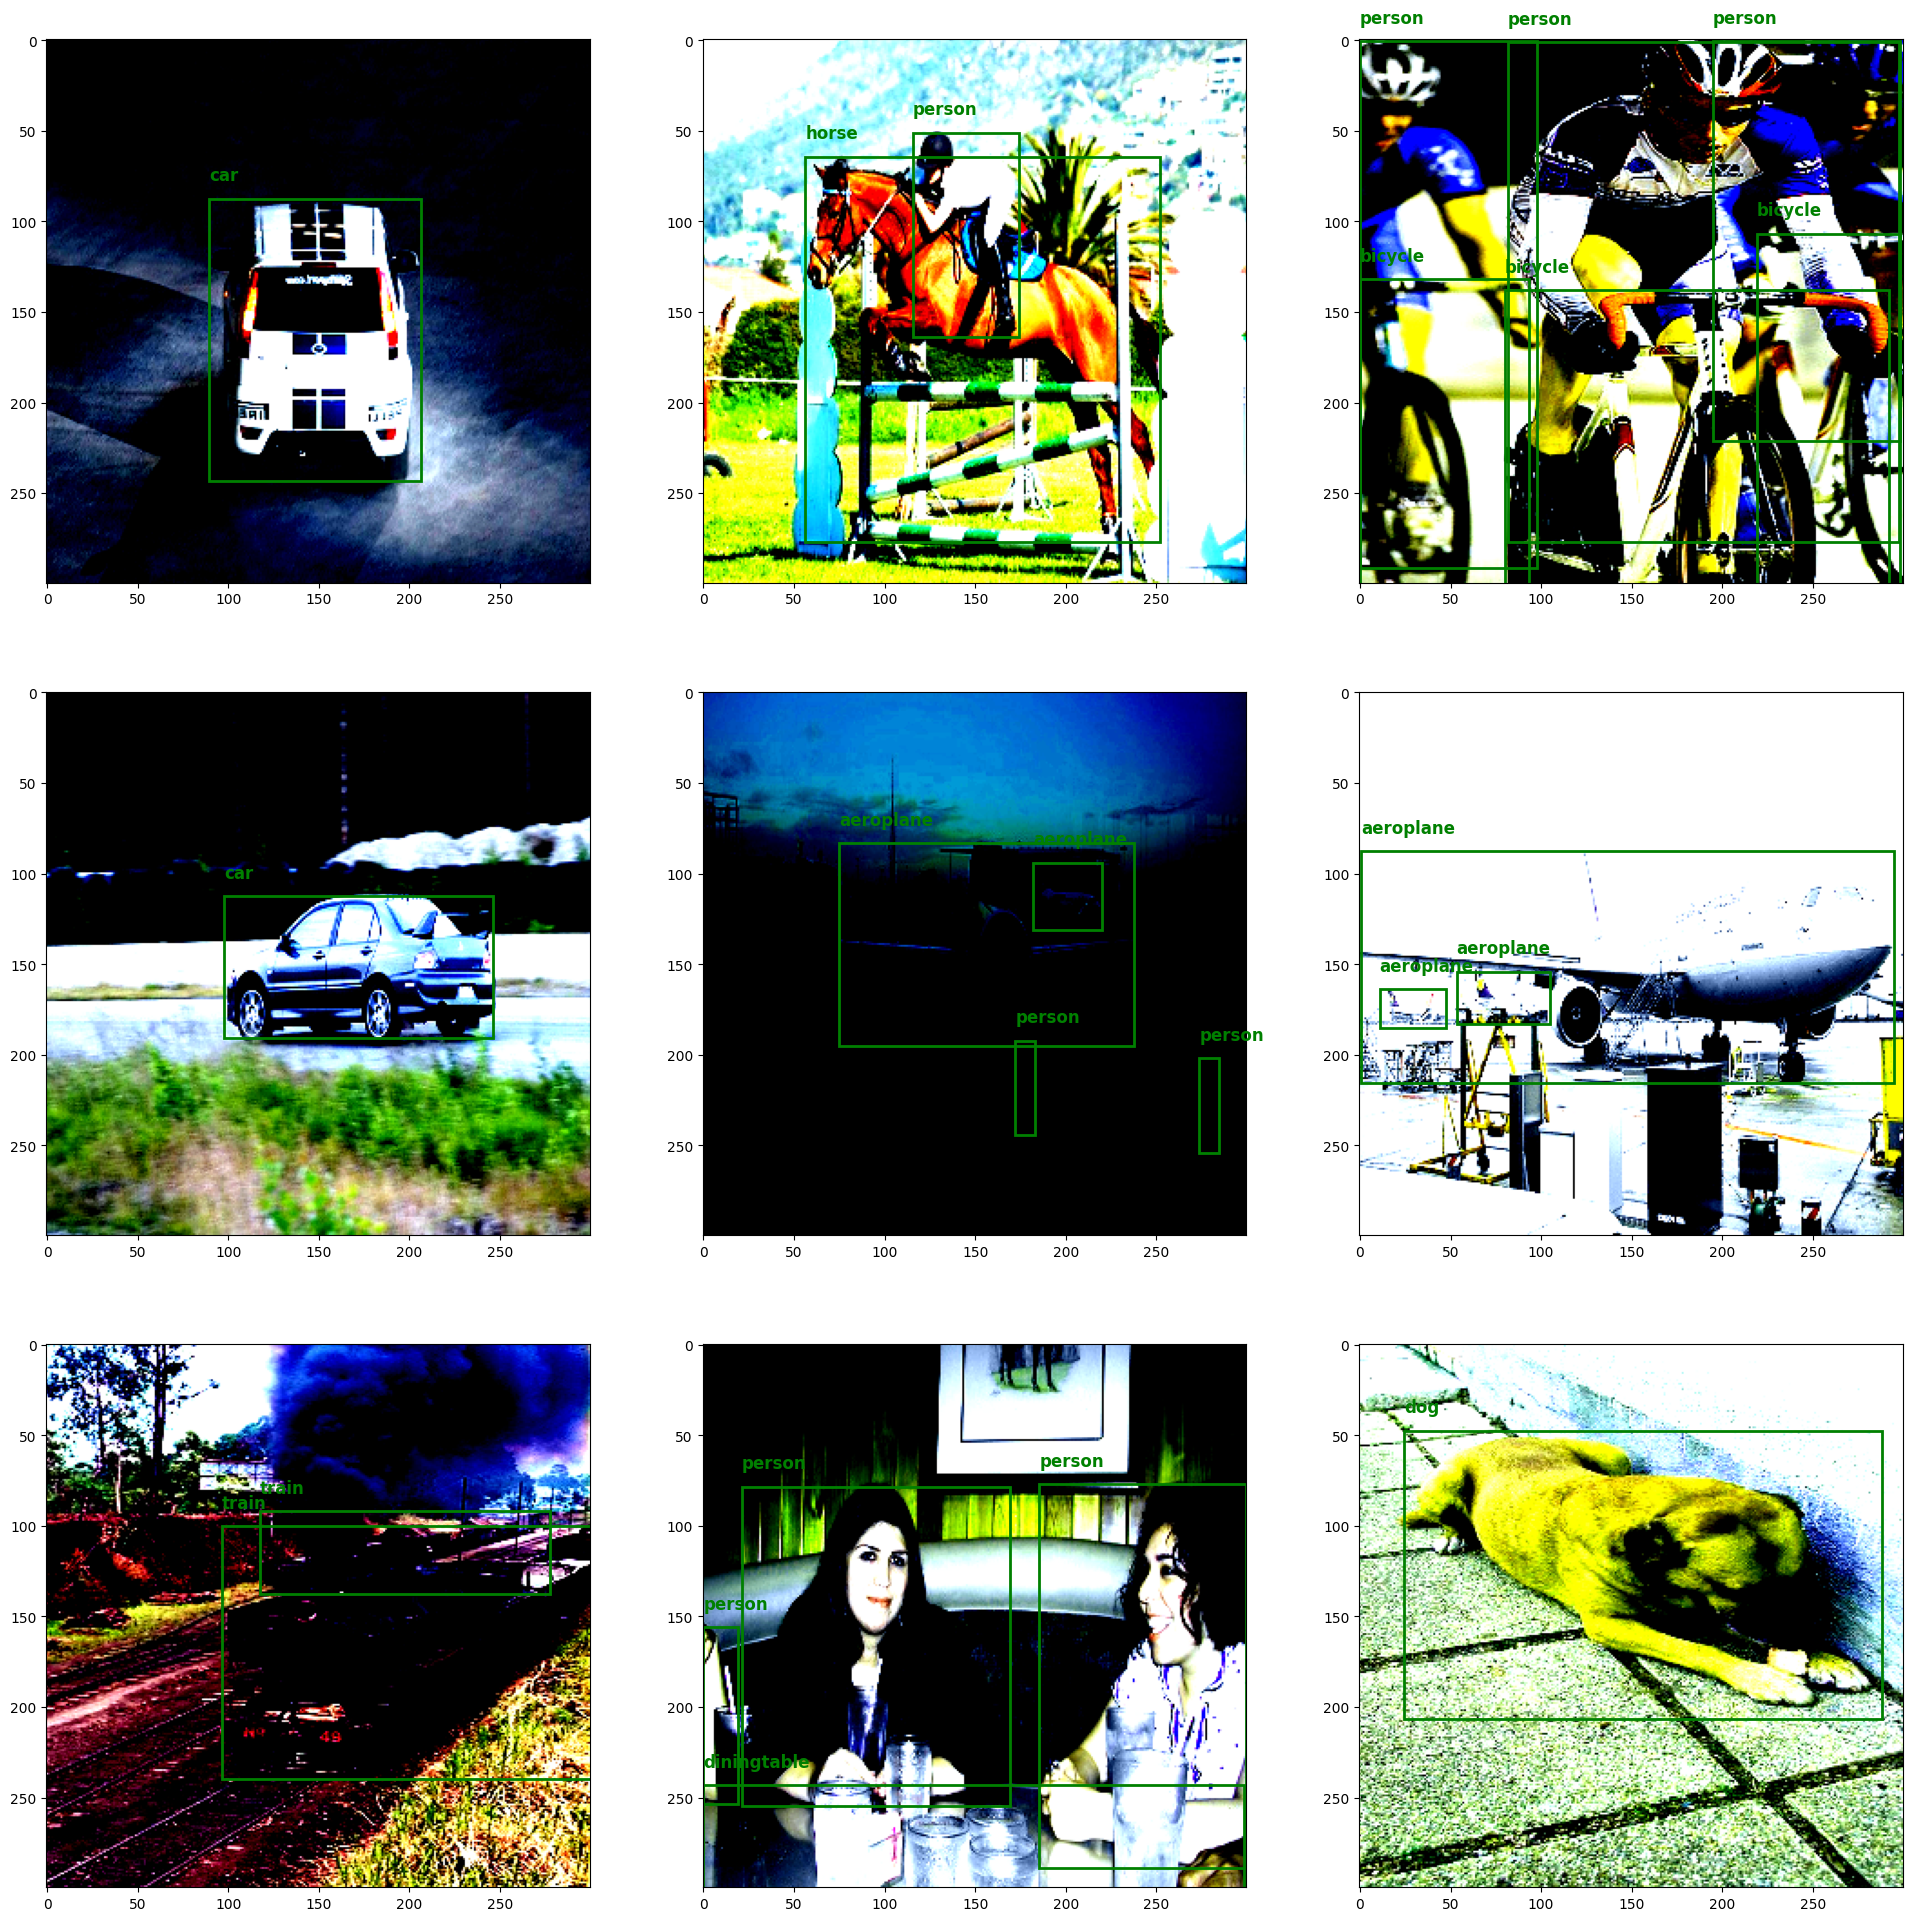

In [30]:
fig, axarr = plt.subplots(3,3, figsize=(24, 24))

axarrs = axarr.flatten()
for img, target, ax in zip(imgs, targets, axarrs):
    ax.imshow(img)
    add_bbs(target, ax)

plt.show()

### **Prepare...**

In [31]:
ssd_net = build_ssd('train')

In [32]:
ssd_net = ssd_net.to(device)
# net = ssd_net.to('cpu')

#### **Initialize weights**

In [33]:
reduced_vgg_weights_path = "weights/vgg16_reducedfc.pth"
vgg_weights = torch.load(reduced_vgg_weights_path, weights_only=True)
ssd_net.vgg.load_state_dict(vgg_weights)

<All keys matched successfully>

In [34]:
def xavier(param):
    # nn.init.xavier_uniform_(param,  gain=nn.init.calculate_gain('relu'))
    nn.init.xavier_uniform_(param)

In [35]:
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        xavier(m.weight.data)
        m.bias.data.zero_()

In [36]:
ssd_net.extras.apply(weights_init)
ssd_net.loc.apply(weights_init)
ssd_net.conf.apply(weights_init)

ModuleList(
  (0): Conv2d(512, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): Conv2d(1024, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): Conv2d(512, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): Conv2d(256, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4-5): 2 x Conv2d(256, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

#### **Optimizer and Custom Loss**

In [37]:
from layers.modules.multibox_loss import MultiBoxLoss

In [38]:
optimizer = optim.SGD(ssd_net.parameters(), lr=1e-3, momentum=0.9,
                        weight_decay=5e-4)
criterion = MultiBoxLoss(voc['num_classes'], voc['variance'], 0.5, True, 0, True, 3, 0.5,
                            False, torch.cuda.is_available())

### **TensorBoard setup**

In [39]:
import torch
from torch.utils.tensorboard import SummaryWriter

In [40]:
output_path = 'runs/SSD_300'
writer = SummaryWriter(output_path)

### **Training Process**

In [41]:
ssd_net.train()

SSD(
  (priorbox): PriorBox()
  (vgg): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, p

In [42]:
def train(net, writer):
    for epoch in range(voc["max_iter"]):
        losses_c = []
        losses_l = []
        for i, (images, labels) in enumerate(train_dataloader):  
            #Move tensors to the configured device
            images = images.to(device)
            # labels = labels.to(device)
            # targets = [Variable(ann, volatile=True) for ann in labels]
            targets = [ann.to(device) for ann in labels]

            # Forward pass
            out = net(images)

            # print(images.device)
            # print(targets[0].device)
            # print(out[2].device)

            optimizer.zero_grad()
            loss_l, loss_c = criterion(out, targets)
            loss = loss_l + loss_c

            # Backprop
            loss.backward()
            optimizer.step()

            losses_c.append(loss_c.detach())
            losses_l.append(loss_l.detach())

        mean_loss_c = sum(losses_c) / len(losses_c)
        mean_loss_l = sum(losses_l) / len(losses_l)

        writer.add_scalar('Training Classification Loss', mean_loss_c, epoch)
        writer.add_scalar('Training Localisation Loss', mean_loss_l, epoch)
        writer.add_scalar('Training Loss', mean_loss_c + mean_loss_l, epoch)

        print(f"epoch: {epoch} || Localisation Loss: {mean_loss_l} || Clasification Loss: {mean_loss_c}")


In [43]:
train(ssd_net, writer)

/home/simens/Envs/default_python_pkgs/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


epoch: 0 || Localisation Loss: 2.800471544265747 || Clasification Loss: 10.766029357910156
epoch: 1 || Localisation Loss: 2.5980916023254395 || Clasification Loss: 6.214604377746582
epoch: 2 || Localisation Loss: 2.468409776687622 || Clasification Loss: 5.132197380065918
epoch: 3 || Localisation Loss: 2.3855607509613037 || Clasification Loss: 5.185659408569336
epoch: 4 || Localisation Loss: 2.3284482955932617 || Clasification Loss: 5.01280403137207
epoch: 5 || Localisation Loss: 2.2767224311828613 || Clasification Loss: 4.770674228668213
epoch: 6 || Localisation Loss: 2.2211296558380127 || Clasification Loss: 4.652063369750977
epoch: 7 || Localisation Loss: 2.1612374782562256 || Clasification Loss: 4.582287788391113
epoch: 8 || Localisation Loss: 2.107057571411133 || Clasification Loss: 4.523306846618652
epoch: 9 || Localisation Loss: 2.0525524616241455 || Clasification Loss: 4.4413957595825195
epoch: 10 || Localisation Loss: 1.9885509014129639 || Clasification Loss: 4.363014221191406


In [63]:
writer.flush()
writer.close()

#### **Saving Process**

In [ ]:
torch.save(ssd_net, "single_shot_detector.pth")